# Random Sample imputation for Categorical Data

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('house-train (1).csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [4]:
df.sample(10)

,FireplaceQu,GarageQual,SalePrice
666,Po,TA,129000
1061,NaN,TA,81000
1174,Gd,TA,239000
792,TA,TA,269790
501,NaN,TA,226700
1206,NaN,TA,107000
1017,Ex,TA,187500
1084,TA,TA,187500
778,TA,TA,144000
232,Po,TA,94500


## Check missing (null) value

In [6]:
df.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

## Create X & Y

In [7]:
x = df
y = df['SalePrice']

## Apply Train Test Split

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [9]:
x_train

,FireplaceQu,GarageQual,SalePrice
455,TA,TA,175500
863,NaN,TA,132500
504,Fa,TA,147000
1413,Gd,TA,257000
1389,Gd,TA,131000
...,...,...,...
466,Po,TA,167000
299,Gd,TA,158500
493,Fa,TA,155000
527,Gd,TA,446261


## New column create in Both Garage & Fire place

In [11]:
x_train['GarageQual_imputed'] = x_train['GarageQual']
x_test['GarageQual_imputed'] = x_test['GarageQual']

x_train['FireplaceQu_imputed'] = x_train['FireplaceQu']
x_test['FireplaceQu_imputed'] = x_test['FireplaceQu']

In [12]:
x_train.sample(10)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
818,NaN,TA,155000,TA,NaN
55,Gd,TA,180500,TA,Gd
299,Gd,TA,158500,TA,Gd
1360,NaN,TA,189000,TA,NaN
236,NaN,TA,185500,TA,NaN
159,Gd,TA,320000,TA,Gd
207,Po,TA,141000,TA,Po
63,NaN,TA,140000,TA,NaN
680,TA,TA,143000,TA,TA
57,NaN,TA,196500,TA,NaN


## Replace Garage Value and Fireplace Imputed

In [13]:
x_train['GarageQual_imputed'][x_train['GarageQual_imputed'].isnull()] = x_train['GarageQual'].dropna().sample(x_train['GarageQual'].isnull().sum()).values
x_test['GarageQual_imputed'][x_test['GarageQual_imputed'].isnull()] = x_test['GarageQual'].dropna().sample(x_test['GarageQual'].isnull().sum()).values

x_train['FireplaceQu_imputed'][x_train['FireplaceQu_imputed'].isnull()] = x_train['FireplaceQu'].dropna().sample(x_train['FireplaceQu'].isnull().sum()).values
x_test['FireplaceQu_imputed'][x_test['FireplaceQu_imputed'].isnull()] = x_test['FireplaceQu'].dropna().sample(x_test['FireplaceQu'].isnull().sum()).values

C:\Users\HP\AppData\Local\Temp\ipykernel_7968\4287893096.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  x_train['GarageQual_imputed'][x_train['GarageQual_imputed'].isnull()] = x_train['GarageQual'].dropna().sample(x_train['GarageQual'].

## Review Frequency in Garage Original & Imputed

In [14]:
temp = pd.concat(
    [
        x_train['GarageQual'].value_counts() / len(x_train['GarageQual'].dropna()),
        x_train['GarageQual_imputed'].value_counts() / len(x_train)
    ],
    axis=1)

temp.columns = ['original', 'imputed']
temp

,original,imputed
TA,0.951043,0.951199
Fa,0.037171,0.037671
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


## Review Frequency in Fireplace Original & Imputed

In [17]:
temp = pd.concat(
    [
        x_train['FireplaceQu'].value_counts() / len(x_train['FireplaceQu'].dropna()),
        x_train['FireplaceQu_imputed'].value_counts() / len(x_train)
    ],
    axis=1)

temp.columns = ['original', 'imputed']
temp

,original,imputed
Gd,0.494272,0.496575
TA,0.412439,0.407534
Fa,0.040917,0.041952
Po,0.027823,0.029110
Ex,0.024550,0.024829


## Compare category Fireplace before Imputation

C:\Users\HP\AppData\Local\Temp\ipykernel_7968\3412570122.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  for category in x_train['FireplaceQu'].dropna().unique(): sns.distplot(x_train[x_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
C:\Users\HP\AppData\Local\Temp\ipykernel_7968\3412570122.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see

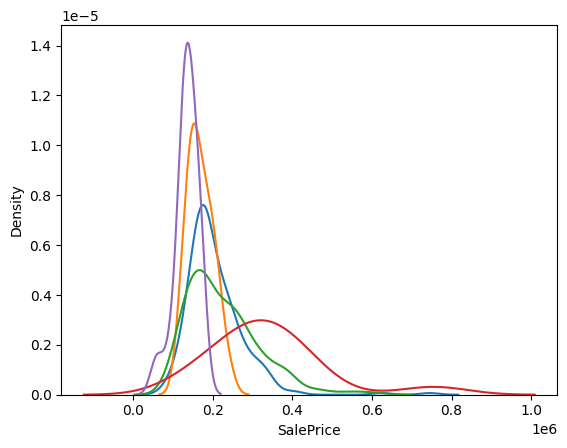

In [18]:
for category in x_train['FireplaceQu'].dropna().unique(): sns.distplot(x_train[x_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.show()

## Compare category fireplace after Imputation

C:\Users\HP\AppData\Local\Temp\ipykernel_7968\2979567757.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  for category in x_train['FireplaceQu_imputed'].dropna().unique(): sns.distplot(x_train[x_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
C:\Users\HP\AppData\Local\Temp\ipykernel_7968\2979567757.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new funct

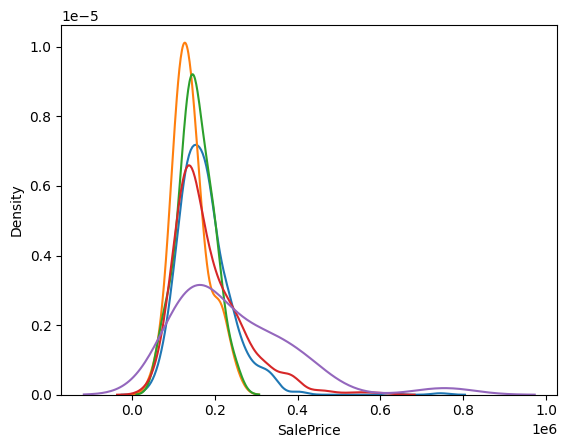

In [19]:
for category in x_train['FireplaceQu_imputed'].dropna().unique(): sns.distplot(x_train[x_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.show()